<a href="https://colab.research.google.com/github/sindla97/Machine-Learning/blob/working-scan/census_bureau_cust_seg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
columns=pd.read_csv('/content/census-bureau.columns',sep=',',names=['columns'])
columns['columns']=columns['columns'].str.replace(' ','_')
columns

,columns
0,age
1,class_of_worker
2,detailed_industry_recode
3,detailed_occupation_recode
4,education
5,wage_per_hour
6,enroll_in_edu_inst_last_wk
7,marital_stat
8,major_industry_code
9,major_occupation_code


In [3]:
df=pd.read_csv('/content/census-bureau.data', sep=",",names=columns['columns'].tolist())
df.head()

,age,class_of_worker,detailed_industry_recode,detailed_occupation_recode,education,wage_per_hour,enroll_in_edu_inst_last_wk,marital_stat,major_industry_code,major_occupation_code,...,country_of_birth_father,country_of_birth_mother,country_of_birth_self,citizenship,own_business_or_self_employed,fill_inc_questionnaire_for_veteran's_admin,veterans_benefits,weeks_worked_in_year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [4]:
#imputing with the most popular category
df['hispanic_origin']=np.where(df['hispanic_origin'].isna(),'All other', df['hispanic_origin'])

In [5]:
df['detailed_occupation_recode']=df['detailed_occupation_recode'].astype('object')
df['detailed_industry_recode']=df['detailed_industry_recode'].astype('object')
df['veterans_benefits']=df['veterans_benefits'].astype('int').astype('object')
df['own_business_or_self_employed']=df['own_business_or_self_employed'].astype('int').astype('object')


In [6]:
df['label']=df['label'].apply(lambda x: 1 if x=='50000+.' else 0)


In [7]:
import pandas as pd

education_map = {

    'Children': 'Low_ed',
    'Less than 1st grade': 'Low_ed',
    '1st 2nd 3rd or 4th grade': 'Low_ed',
    '5th or 6th grade': 'Low_ed',
    '7th and 8th grade': 'Low_ed',
    '9th grade': 'Low_ed',
    '10th grade': 'Low_ed',
    '11th grade': 'Low_ed',
    '12th grade no diploma': 'Low_ed',

    'High school graduate': 'HS-College',
    'Some college but no degree': 'HS-College',
    'Associates degree-academic program': 'HS-College',
    'Associates degree-occup /vocational': 'HS-College',
    'Bachelors degree(BA AB BS)': 'Professional',
    'Masters degree(MA MS MEng MEd MSW MBA)': 'Professional',

    'Doctorate degree(PhD EdD)': 'Professional',
    'Prof school degree (MD DDS DVM LLB JD)': 'Professional'
}

df['education'] = df['education'].map(education_map)


In [8]:
# dropping "state_of_previous_residence" as we already have 'region_of_previous_residence'
# dropping 'country_of_birth_father' & 'country_of_birth_mother' because of high cardinality and high associate with 'country_of_birth_self'
# dropping 'detailed_industry_recode', 'detailed_occupation_recode becuase we have 'detailed_industry_recode', 'detailed_occupation_recode'
df.drop(columns=['state_of_previous_residence','country_of_birth_father','country_of_birth_mother','detailed_industry_recode','detailed_occupation_recode','year'],axis=1, inplace=True)

In [9]:
unique_cnt=[]
data_type_df=df.dtypes.reset_index(name='data_type')
data_type_df

for i in data_type_df['index'].tolist():
  #print(data_type_df.loc[data_type_df['index']==i,'data_type'])
  if data_type_df.loc[data_type_df['index'] == i, 'data_type'].iloc[0] == 'object':
    unique_cnt.append(df[i].nunique())
  else: unique_cnt.append(0)
#print(unique_cnt)
data_type_df['nunique']=pd.Series(unique_cnt)
data_type_df

# df['class_of_worker'].unique().tolist()

,index,data_type,nunique
0,age,int64,0
1,class_of_worker,object,9
2,education,object,3
3,wage_per_hour,int64,0
4,enroll_in_edu_inst_last_wk,object,3
5,marital_stat,object,7
6,major_industry_code,object,24
7,major_occupation_code,object,15
8,race,object,5
9,hispanic_origin,object,9


(array([9., 8., 4., 3., 3., 5., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 0., 0., 0., 1., 0., 1.]),
 array([ 0.  ,  1.72,  3.44,  5.16,  6.88,  8.6 , 10.32, 12.04, 13.76,
        15.48, 17.2 , 18.92, 20.64, 22.36, 24.08, 25.8 , 27.52, 29.24,
        30.96, 32.68, 34.4 , 36.12, 37.84, 39.56, 41.28, 43.  ]),
 <BarContainer object of 25 artists>)

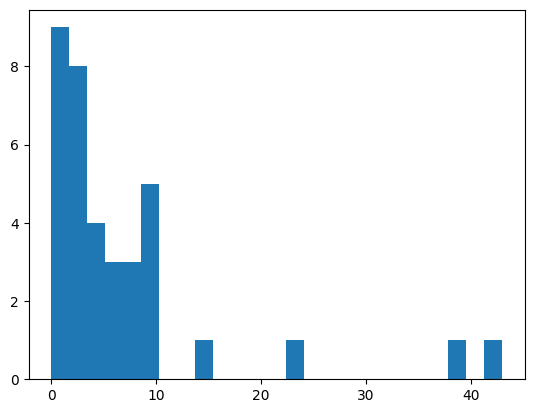

In [10]:
import matplotlib.pyplot as plt
plt.hist(data_type_df['nunique'], bins=25)

In [11]:
df['detailed_household_summary_in_household'].value_counts()

,count
detailed_household_summary_in_household,
Householder,75475
Child under 18 never married,50426
Spouse of householder,41709
Child 18 or older,14430
Other relative of householder,9703
Nonrelative of householder,7601
Group Quarters- Secondary individual,132
Child under 18 ever married,47


In [12]:
# states_df=df.groupby(['state_of_previous_residence'])['label'].mean().reset_index(name='mt').sort_values(by='mt',ascending=False)
# states_df['value']=states_df['mt'].apply(lambda x: 'High_value' if x>0.07 else 'Med_value' if x>0.03 and x<=0.07 else 'Low_val')
# states_dict={}
# for i in states_df['state_of_previous_residence'].tolist():
#   states_dict[i]=states_df.loc[states_df['state_of_previous_residence']==i,'value'].iloc[0]
# states_dict

In [13]:
target='label'
sample_weight='weight'
cat_l_cardinal_col= [x for x in data_type_df.loc[(data_type_df['data_type']=='object') &(data_type_df['nunique']<=4),'index'].tolist() if x not in [target,sample_weight]]
cat_h_cardinal_col= [x for x in data_type_df.loc[data_type_df['data_type']=='object','index'].tolist() if x not in [target,sample_weight]+cat_l_cardinal_col]
int_columns= [x for x in data_type_df.loc[data_type_df['data_type']=='int64','index'].tolist() if x not in [target,sample_weight]]
print(len(cat_l_cardinal_col), len(cat_h_cardinal_col), len(int_columns))

9 18 7


In [14]:
df.replace({'?': 'unknown'}, inplace=True)


/tmp/ipython-input-2489076534.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'?': 'unknown'}, inplace=True)


In [15]:
cat_feat_exp = pd.DataFrame()

for i in cat_h_cardinal_col:
  v_counts=df[i].value_counts().reset_index(name='value_counts').rename(columns={f'{i}':'values'})
  v_counts['value_counts_percent']=(v_counts['value_counts']/df.shape[0])*100

  v_counts['feature']=i
  cat_feat_exp=pd.concat([cat_feat_exp,v_counts], axis=0,ignore_index=True)
cat_feat_exp=cat_feat_exp.merge(data_type_df, left_on='feature', right_on='index')
cat_feat_exp


,values,value_counts,value_counts_percent,feature,index,data_type,nunique
0,Not in universe,100245,50.242328,class_of_worker,class_of_worker,object,9
1,Private,72028,36.100099,class_of_worker,class_of_worker,object,9
2,Self-employed-not incorporated,8445,4.232595,class_of_worker,class_of_worker,object,9
3,Local government,7784,3.901305,class_of_worker,class_of_worker,object,9
4,State government,4227,2.118553,class_of_worker,class_of_worker,object,9
...,...,...,...,...,...,...,...
218,Native- Born in the United States,176992,88.707568,citizenship,citizenship,object,5
219,Foreign born- Not a citizen of U S,13401,6.716519,citizenship,citizenship,object,5
220,Foreign born- U S citizen by naturalization,5855,2.934499,citizenship,citizenship,object,5
221,Native- Born abroad of American Parent(s),1756,0.880099,citizenship,citizenship,object,5


In [16]:
hcard_converge=cat_feat_exp[((cat_feat_exp['value_counts_percent']<=5)&(cat_feat_exp['nunique']<=10)) |((cat_feat_exp['value_counts_percent']<=3) &(cat_feat_exp['nunique']>=10))]



In [17]:
for i in cat_h_cardinal_col:
  comp_cat = hcard_converge.loc[hcard_converge['feature'] == i, 'values'].tolist()

  df[i] = df[i].where(~df[i].isin(comp_cat), 'other')
  # print(df[i].value_counts())

In [18]:
for i in int_columns:
  if i in ['wage_per_hour','capital_gains','capital_losses','dividends_from_stocks']:
    df[i]=np.where(df[i]==0,0, np.log1p(df[i]))


In [19]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
global_mean = df[target].mean()

for feature in cat_h_cardinal_col:

  pop_map = df[feature].value_counts()/df.shape[0]
  df[f'{feature}_enc_pop'] = df[feature].map(pop_map)
  df[f'{feature}_enc_pop'].fillna(global_mean, inplace=True)

## Kmean(with scaled fetaures)
may be use PCA to cutdown on dimentionality and apply K Means
##final_columns =int_columns(log transformed+ scaled)+cat_h_cardinal_col(frequncy encoded+scaled)+cat_l_cardinal_col(one hot encoded)


In [21]:
cat_l_cardinal_col_encoded=[]
# df['label']=df['label'].astype('category')

from sklearn.preprocessing import OneHotEncoder
for i in cat_l_cardinal_col:

  oe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')


  encoded = oe.fit_transform(df[[i]])

  encoded_cols = oe.get_feature_names_out([i])

  train_encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=df.index)

  df = pd.concat([df, train_encoded_df], axis=1)
  cat_l_cardinal_col_encoded.extend(encoded_cols)


In [22]:
final_features_kmeans=[x for x in int_columns if x not in ['year']]+cat_l_cardinal_col_encoded+[f'{x}_enc_pop' for x in cat_h_cardinal_col]
final_features_kmeans

['age',
 'wage_per_hour',
 'capital_gains',
 'capital_losses',
 'dividends_from_stocks',
 'num_persons_worked_for_employer',
 'weeks_worked_in_year',
 'education_HS-College',
 'education_Low_ed',
 'education_Professional',
 'enroll_in_edu_inst_last_wk_College or university',
 'enroll_in_edu_inst_last_wk_High school',
 'enroll_in_edu_inst_last_wk_Not in universe',
 'sex_Female',
 'sex_Male',
 'member_of_a_labor_union_No',
 'member_of_a_labor_union_Not in universe',
 'member_of_a_labor_union_Yes',
 'live_in_this_house_1_year_ago_No',
 'live_in_this_house_1_year_ago_Not in universe under 1 year old',
 'live_in_this_house_1_year_ago_Yes',
 'migration_prev_res_in_sunbelt_No',
 'migration_prev_res_in_sunbelt_Not in universe',
 'migration_prev_res_in_sunbelt_Yes',
 'migration_prev_res_in_sunbelt_unknown',
 'own_business_or_self_employed_0',
 'own_business_or_self_employed_1',
 'own_business_or_self_employed_2',
 "fill_inc_questionnaire_for_veteran's_admin_No",
 "fill_inc_questionnaire_for_vet

In [23]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
df_scaled_km=ss.fit_transform(df[[x for x in final_features_kmeans if x not in cat_l_cardinal_col_encoded]])

df_scaled_km=np.concatenate((df_scaled_km, df[cat_l_cardinal_col_encoded].to_numpy()), axis=1)

df_scaled_km
# pd.conact([df,df_scaled],axis=1)

array([[ 1.72587866, -0.24430994, -0.19446972, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.05355971, -0.24430994, -0.19446972, ...,  0.        ,
         0.        ,  1.        ],
       [-0.73929082, -0.24430994, -0.19446972, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.56052581, -0.24430994, -0.19446972, ...,  0.        ,
         0.        ,  1.        ],
       [-0.82893335, -0.24430994, -0.19446972, ...,  0.        ,
         0.        ,  1.        ],
       [-0.11179313, -0.24430994, -0.19446972, ...,  0.        ,
         0.        ,  1.        ]])

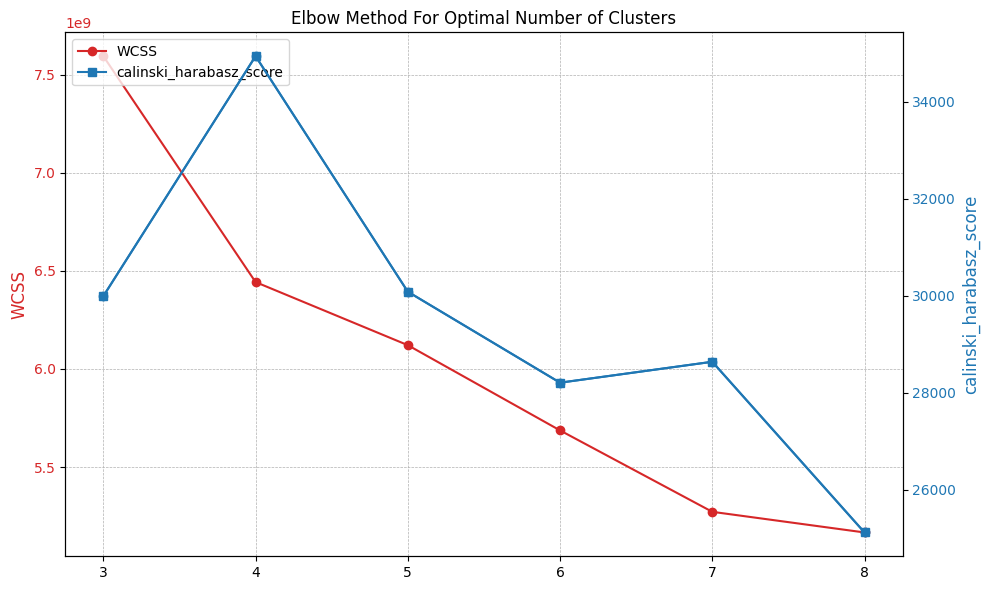

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,calinski_harabasz_score

interia = []
scores=[]
for i in range(3,9):
  km=KMeans(n_clusters=i,random_state=42, n_init='auto')
  labels = km.fit_predict(df_scaled_km, sample_weight=df[sample_weight])
  interia.append(km.inertia_)
  scores.append(calinski_harabasz_score(df_scaled_km, labels))


fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_ylabel('WCSS', color=color, fontsize=12)
ax1.plot(range(3, 9), interia, color=color, marker='o', label='WCSS')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('calinski_harabasz_score', color=color, fontsize=12)
ax2.plot(range(3, 9), scores, color=color, marker='s', label='calinski_harabasz_score')
ax2.tick_params(axis='y', labelcolor=color)


lines = [ax1.get_lines()[0], ax2.get_lines()[0]]
ax1.legend(lines, [line.get_label() for line in lines], loc='upper left')


plt.plot(range(3, 9), scores, marker='o')
plt.title('Elbow Method For Optimal Number of Clusters')
fig.tight_layout()
plt.show()



In [ ]:
# from sklearn.metrics import silhouette_score

# scores = []
# for k in range(3, 10):
#     km = KMeans(n_clusters=k, random_state=42)
#     labels = km.fit_predict(df_scaled, sample_weight=df[sample_weight])
#     scores.append(silhouette_score(df_scaled, labels))

# plt.plot(range(3, 10), scores, 'o-')
# plt.xlabel('Number of clusters')
# plt.ylabel('Silhouette Score')
# plt.show()

#using PCA to cutdown on dimentionality and apply K Means

##final_columns=int_columns(log transformed+ scaled)+cat_h_cardinal_col(frequncy encoded+scaled)+cat_l_cardinal_col(frequncy encoded+scaled)

In [27]:
#one hot encoding does not make sense when using PCA
global_mean = df[target].mean()

for feature in cat_l_cardinal_col:

  pop_map = df[feature].value_counts()/df.shape[0]
  df[f'{feature}_enc_pop'] = df[feature].map(pop_map)
  df[f'{feature}_enc_pop'].fillna(global_mean, inplace=True)

In [28]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
df_scaled=ss.fit_transform(df[[x for x in final_features_kmeans if x not in cat_l_cardinal_col_encoded]+[f'{x}_enc_pop' for x in cat_l_cardinal_col]])
df_scaled

array([[ 1.72587866, -0.24430994, -0.19446972, ...,  0.32287147,
         0.10021739,  0.57083228],
       [ 1.05355971, -0.24430994, -0.19446972, ...,  0.32287147,
         0.10021739,  0.57083228],
       [-0.73929082, -0.24430994, -0.19446972, ...,  0.32287147,
         0.10021739,  0.57083228],
       ...,
       [ 0.56052581, -0.24430994, -0.19446972, ...,  0.32287147,
         0.10021739,  0.57083228],
       [-0.82893335, -0.24430994, -0.19446972, ...,  0.32287147,
         0.10021739,  0.57083228],
       [-0.11179313, -0.24430994, -0.19446972, ...,  0.32287147,
         0.10021739,  0.57083228]])

(199523, 18)


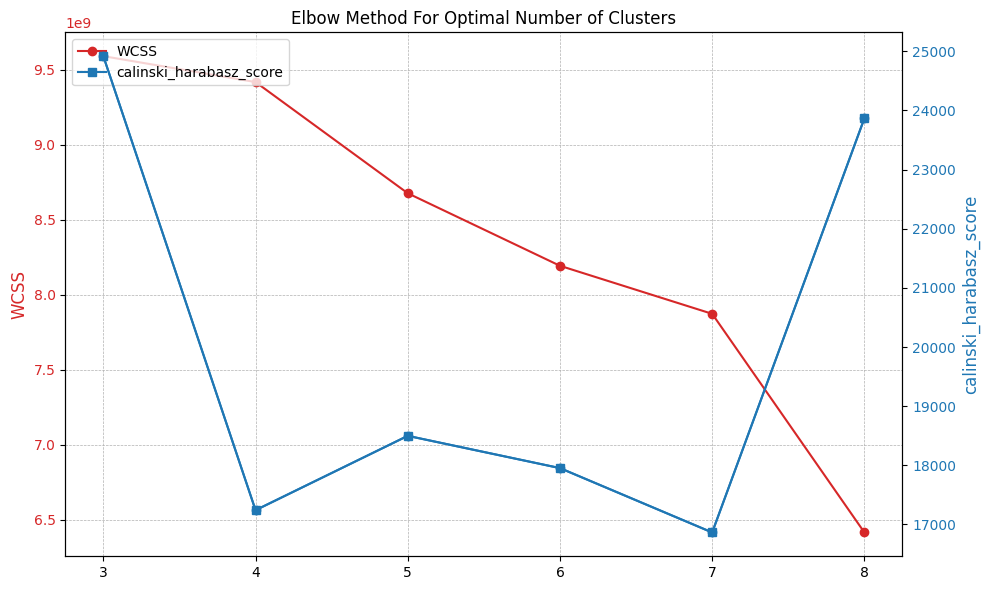

In [30]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
pca = PCA(n_components=0.9)
df_scaled_pca=pca.fit_transform(df_scaled)
print(df_scaled_pca.shape)
interia = []
scores=[]
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(df_scaled, sample_weight=df[sample_weight])
    interia.append(km.inertia_)
    scores.append(calinski_harabasz_score(df_scaled, labels))


fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_ylabel('WCSS', color=color, fontsize=12)
ax1.plot(range(3, 9), interia, color=color, marker='o', label='WCSS')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('calinski_harabasz_score', color=color, fontsize=12)
ax2.plot(range(3, 9), scores, color=color, marker='s', label='calinski_harabasz_score')
ax2.tick_params(axis='y', labelcolor=color)


lines = [ax1.get_lines()[0], ax2.get_lines()[0]]
ax1.legend(lines, [line.get_label() for line in lines], loc='upper left')


plt.plot(range(3, 9), scores, marker='o')
plt.title('Elbow Method For Optimal Number of Clusters')
fig.tight_layout()
plt.show()

#kprototypes form kmodes

In [31]:
!pip install kmodes

##final_columns =int_columns(log transformed+ scaled)+cat_l_cardinal_col(label encoded)+cat_h_cardinal_col(label encoded)


In [32]:
#int_columns & cat_h_cardinal_col has to be standardscaled
#cat_l_cardinal_col + cat_h_cardinal_colhas to be label endcoded

In [33]:
from sklearn.preprocessing import LabelEncoder
for i in cat_h_cardinal_col+cat_h_cardinal_col:
  le=LabelEncoder()
  df[i]=le.fit_transform(df[i])
  df[i]=df[i].astype('category')

In [34]:
ss=StandardScaler()
df_scaled_kp=ss.fit_transform(df[int_columns])

df_scaled_kp=pd.concat([pd.DataFrame(data=df_scaled_kp, columns=int_columns), df[cat_h_cardinal_col+cat_h_cardinal_col]], axis=1)

df_scaled_kp

,age,wage_per_hour,capital_gains,capital_losses,dividends_from_stocks,num_persons_worked_for_employer,weeks_worked_in_year,class_of_worker,marital_stat,major_industry_code,...,tax_filer_stat,region_of_previous_residence,detailed_household_and_family_stat,detailed_household_summary_in_household,migration_code-change_in_msa,migration_code-change_in_reg,migration_code-move_within_reg,family_members_under_18,country_of_birth_self,citizenship
0,1.725879,-0.24431,-0.19447,-0.141199,-0.320914,-0.827096,-0.949346,0,3,4,...,1,0,6,4,3,2,2,2,0,1
1,1.053560,-0.24431,-0.19447,-0.141199,-0.320914,-0.404284,1.180804,2,0,6,...,3,1,2,2,0,1,1,2,0,1
2,-0.739291,-0.24431,-0.19447,-0.141199,-0.320914,-0.827096,-0.949346,0,2,4,...,1,0,0,0,3,2,2,2,1,0
3,-1.142682,-0.24431,-0.19447,-0.141199,-0.320914,-0.827096,-0.949346,0,2,4,...,1,0,1,1,1,0,0,0,0,1
4,-1.097861,-0.24431,-0.19447,-0.141199,-0.320914,-0.827096,-0.949346,0,2,4,...,1,0,1,1,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,2.353376,-0.24431,-0.19447,-0.141199,-0.320914,-0.827096,-0.949346,0,1,4,...,3,0,2,2,3,2,2,2,0,1
199519,1.367309,-0.24431,5.12320,-0.141199,0.900540,-0.404284,1.180804,2,1,6,...,3,0,2,2,1,0,0,2,0,1
199520,0.560526,-0.24431,-0.19447,-0.141199,2.364644,1.709774,1.180804,0,1,4,...,0,0,2,2,3,2,2,2,1,2
199521,-0.828933,-0.24431,-0.19447,-0.141199,-0.320914,-0.827096,-0.949346,0,2,4,...,1,0,1,1,3,2,2,0,0,1


In [36]:
cat_cols=cat_h_cardinal_col+cat_h_cardinal_col

# print(np.argmax(df_scaled.columns.get_loc(cat_cols[0])) )
cat_idx = list(set([int(np.argmax(df_scaled_kp.columns.get_loc(c))) for c in cat_cols]))
cat_idx

[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 87355, ncost: 9293050784.434925
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 92359, ncost: 9422369030.322886
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 3, iteration: 1/100, moves: 56961, ncost: 8208455999.35639
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 4, iteration: 1/100, moves: 54641, ncost: 9744927705.422401
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 5, iteration: 1/100, moves: 39232, ncost: 8732552876.747269
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 6, iteration: 1/100, moves: 46098, ncost: 7326264297.5017
Init: initializing centroids
Init: initializing clusters


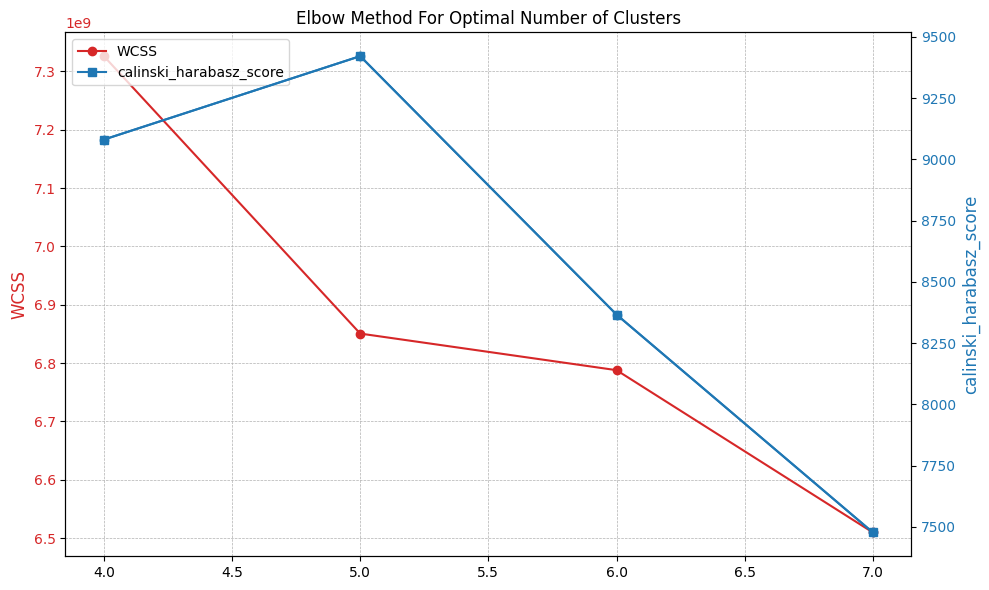

In [37]:
from kmodes.kprototypes import KPrototypes
interia = []
scores=[]
for k in range(4, 8):
    kproto = KPrototypes(n_clusters=k, init='Cao', verbose=1, random_state=42)
    labels = kproto.fit_predict(df_scaled_kp.values, sample_weight=df[sample_weight],categorical=cat_idx)
    interia.append(kproto.cost_)
    scores.append(calinski_harabasz_score(df_scaled, labels))

# Plot the elbow graph
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_ylabel('WCSS', color=color, fontsize=12)
ax1.plot(range(4, 8), interia, color=color, marker='o', label='WCSS')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('calinski_harabasz_score', color=color, fontsize=12)
ax2.plot(range(4, 8), scores, color=color, marker='s', label='calinski_harabasz_score')
ax2.tick_params(axis='y', labelcolor=color)


lines = [ax1.get_lines()[0], ax2.get_lines()[0]]
ax1.legend(lines, [line.get_label() for line in lines], loc='upper left')


plt.plot(range(4, 8), scores, marker='o')
plt.title('Elbow Method For Optimal Number of Clusters')
fig.tight_layout()
plt.show()



In [38]:
#based on KModes we can have 5 optimal clusters
kproto = KPrototypes(n_clusters=5, init='Cao', verbose=1, random_state=42)
labels = kproto.fit_predict(df_scaled_kp.values, sample_weight=df[sample_weight],categorical=cat_idx)
df['clusters']=labels


Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 64846, ncost: 7748411846.693373
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 97953, ncost: 8652304787.339428
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 3, iteration: 1/100, moves: 70295, ncost: 8109332697.657846
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 4, iteration: 1/100, moves: 61273, ncost: 9752733184.369108
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 5, iteration: 1/100, moves: 48625, ncost: 8050295612.423133
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 6, iteration: 1/100, moves: 45343, ncost: 6850640638.642943
Init: initializing centroids
Init: initializing cluste

In [40]:
df.to_csv('/content/census_bureau_wclusters.csv')

In [42]:
df.groupby('clusters')[int_columns+[target]].mean()

,age,wage_per_hour,capital_gains,capital_losses,dividends_from_stocks,num_persons_worked_for_employer,weeks_worked_in_year,label
clusters,,,,,,,,
0,48.553670,0.435409,8.685865,0.000000,1.818046,3.216749,39.634796,0.332643
1,12.515011,0.105982,0.000407,0.031229,0.044454,0.527131,4.837297,0.001787
2,52.549874,0.282288,0.004591,0.237214,0.962693,2.006277,23.732646,0.064837
3,43.868816,0.405388,0.007517,0.137621,0.786148,2.204403,25.668533,0.059110
4,37.867903,0.852828,0.009948,0.307511,0.703311,3.564941,44.962950,0.110315


In [57]:
pd.DataFrame(data=kproto.cluster_centroids_, index=range(1,6), columns=df_scaled_kp.columns)

,age,wage_per_hour,capital_gains,capital_losses,dividends_from_stocks,num_persons_worked_for_employer,weeks_worked_in_year,class_of_worker,marital_stat,major_industry_code,...,tax_filer_stat,region_of_previous_residence,detailed_household_and_family_stat,detailed_household_summary_in_household,migration_code-change_in_msa,migration_code-change_in_reg,migration_code-move_within_reg,family_members_under_18,country_of_birth_self,citizenship
1,0.441326,0.105794,3.945607,0.032197,0.504102,0.604973,0.693184,1.007075,1.237949,4.122196,...,0.0,0.0,2.0,2.0,3.0,2.0,2.0,2.0,0.0,1.0
2,-0.774390,-0.138010,-0.164435,-0.062380,-0.246300,-0.475447,-0.595412,0.155214,1.680908,3.486205,...,1.0,0.0,1.0,1.0,3.0,2.0,2.0,0.0,0.0,1.0
3,1.023644,-0.067946,-0.217977,0.170390,0.336136,0.210660,0.156918,0.944922,1.879312,4.471606,...,0.0,0.0,2.0,2.0,3.0,2.0,2.0,2.0,0.0,1.0
4,0.389669,-0.000364,-0.176636,-0.066701,0.061127,0.023673,0.013802,0.607989,1.386585,4.158446,...,0.0,0.0,5.0,3.0,1.0,0.0,0.0,2.0,0.0,1.0
5,0.166264,0.335350,-0.209442,0.133641,0.073506,0.748306,0.970260,1.377837,1.458625,5.614530,...,0.0,0.0,2.0,2.0,1.0,0.0,0.0,2.0,0.0,1.0


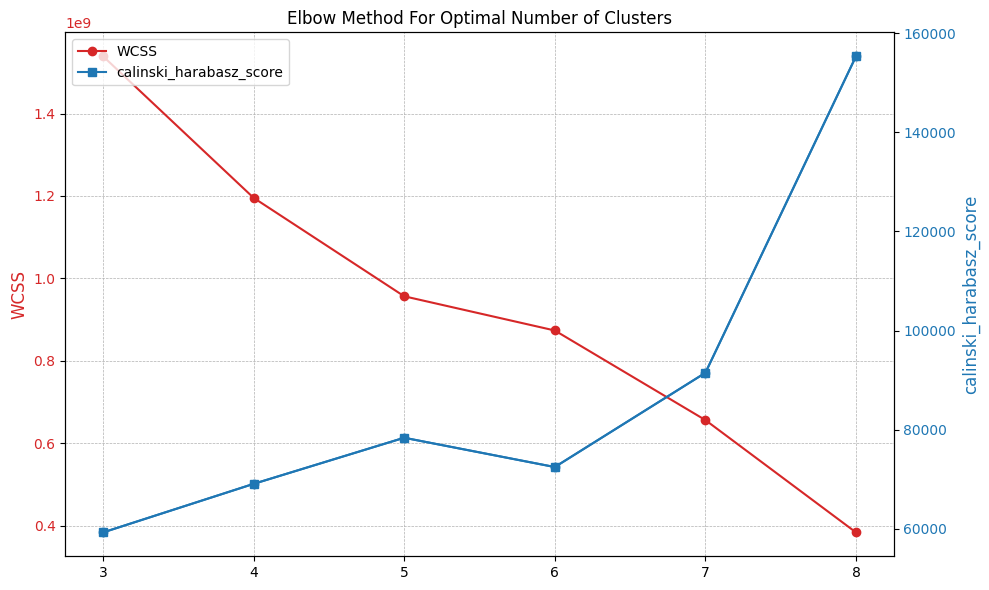

In [58]:
ss=StandardScaler()
df_scaled_km_int=ss.fit_transform(df[int_columns])


df_scaled_km_int

interia = []
scores=[]
for i in range(3,9):
  km_int=KMeans(n_clusters=i,random_state=42, n_init='auto')
  labels = km_int.fit_predict(df_scaled_km_int, sample_weight=df[sample_weight])
  interia.append(km_int.inertia_)
  scores.append(calinski_harabasz_score(df_scaled_km_int, labels))


fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_ylabel('WCSS', color=color, fontsize=12)
ax1.plot(range(3, 9), interia, color=color, marker='o', label='WCSS')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('calinski_harabasz_score', color=color, fontsize=12)
ax2.plot(range(3, 9), scores, color=color, marker='s', label='calinski_harabasz_score')
ax2.tick_params(axis='y', labelcolor=color)


lines = [ax1.get_lines()[0], ax2.get_lines()[0]]
ax1.legend(lines, [line.get_label() for line in lines], loc='upper left')


plt.plot(range(3, 9), scores, marker='o')
plt.title('Elbow Method For Optimal Number of Clusters')
fig.tight_layout()
plt.show()

